In [ ]:
from collections import defaultdict

import numpy as np
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm
import torch
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt

from methylseqnet_repro.paths import configs, atac_atlas, methylation_atlas, preprocessed_datasets
from methylseqnet.dataset import BaseHDF5Dataset

In [4]:
def collate_fn(batch):
    # Separate your data into different types
    collated_batch = {}
    for key, value in batch[0].items():
        if isinstance(value, str):
            collated_batch[key] = [item[key] for item in batch]
        elif isinstance(value, torch.Tensor):
            collated_batch[key] = torch.stack([item[key] for item in batch])
        elif isinstance(value, np.ndarray):
            collated_batch[key] = np.stack([item[key] for item in batch])
        else:
            raise TypeError(f"Unsupported data type for key {key}: {type(value)}")
    return collated_batch
longread_folder = preprocessed_datasets / "gm12878_haplotyped"

In [20]:


model_identifiers = ["slurm31983102task0/fold3_truecondweight_1.0","slurm31983102task0/fold3_truecondweight_0.0"] #"slurm31986468task1"]
# model_identifiers = ["slurm31983102task0/fold3_truecondweight_1.0","slurm31986468task1/fold3"]
# model_identifiers = ["slurm31983102task0/fold3_truecondweight_0.0","slurm31986468task1/fold3"]

datasets_to_load = {'tracks','predictions','true_conditioning_state_rep','imputed_conditioning_state_rep','cpg_density',} #'conditional_seq_rep','unconditional_seq_rep'}
datasets_to_load_fallback = {'tracks','predictions','cpg_density'}

fold = 3
max_samples = None

pearson_correlations_dict = defaultdict(lambda: defaultdict(dict))

for model_idx, model_identifier in enumerate(model_identifiers):
    dataset_path = longread_folder / model_identifier / "predictions.h5"
    try:
        dataset = BaseHDF5Dataset(dataset_path,datasets=datasets_to_load,return_specifiers=True)
    except Exception as e:
        print(e)
        dataset = BaseHDF5Dataset(dataset_path,datasets=datasets_to_load_fallback,return_specifiers=True)
    io_mappings_df = dataset.get_io_mappings_df()
    fiber_channels = io_mappings_df[io_mappings_df['data_type']=='Fiber-seq']['channel'].tolist()
    rna_channels = io_mappings_df[io_mappings_df['data_type']=='RNA-seq']['channel'].tolist()
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)
    targets_list = []
    predictions_list = []
    # methylations_list = []
    # imputed_methylations_list = []
    # cpg_density_list = []
    regions_list = []
    chromosome_list = []
    for idx, sample in tqdm(enumerate(dataloader),total=max_samples if max_samples is not None else len(dataloader)):
        if max_samples is not None and idx >= max_samples:
            break
        targets_list.append(sample['tracks'].squeeze().numpy())
        predictions_list.append(sample['predictions'].squeeze().numpy())
        # methylations_list.append(sample.get('true_conditioning_state_rep', sample['tracks']).squeeze().numpy())
        # imputed_methylations_list.append(sample.get('imputed_conditioning_state_rep', sample['predictions']).squeeze().numpy())
        # cpg_density_list.append(sample['cpg_density'].squeeze().numpy())
        region_str = sample['specifier'][0][0].split('|')[0]
        chromosome_list.append(region_str.split(':')[0])
        regions_list.append(region_str)

    in_chrX = [i for i, chrom in enumerate(chromosome_list) if chrom.startswith('chrX')]
    not_in_chrX = [i for i, chrom in enumerate(chromosome_list) if not chrom.startswith('chrX')]
    all_indices = list(range(len(chromosome_list)))

    print(f"Model: {model_identifier}")

    for data_type, channels in ("Fiber-seq",fiber_channels), ("RNA-seq",rna_channels):
        for list_description, list_subset in ("chrX",in_chrX), ("autosomes",not_in_chrX), ("all",all_indices):
            all_targets = np.concatenate([targets_list[i] for i in list_subset],axis=2)
            all_predictions = np.concatenate([predictions_list[i] for i in list_subset],axis=2)
            # all_methylations = np.concatenate(methylations_list, axis=2)
            # all_imputed_methylations = np.concatenate(imputed_methylations_list, axis=2)
            # all_cpg_densities = np.concatenate(cpg_density_list, axis=0)
            subset_targets = all_targets[..., channels, :]
            subset_predictions = all_predictions[..., channels, :]
            for track_idx in range(subset_targets.shape[-2]):
                track_targets = subset_targets[..., track_idx, :].flatten()
                track_predictions = subset_predictions[..., track_idx, :].flatten()
                track_targets_summed = subset_targets[..., track_idx, :].sum(axis=0).flatten()
                track_predictions_summed = subset_predictions[..., track_idx, :].sum(axis=0).flatten()
                track_targets_differential = (subset_targets[0, track_idx, :] - subset_targets[1, track_idx, :]).flatten()
                track_predictions_differential = (subset_predictions[0, track_idx, :] - subset_predictions[1, track_idx, :]).flatten()
                pearson_corr, pearson_p = pearsonr(track_targets, track_predictions)
                spearman_corr, _ = spearmanr(track_targets, track_predictions)
                pearson_corr_summed, pearson_p_summed = pearsonr(track_targets_summed, track_predictions_summed)
                spearman_corr_summed, _ = spearmanr(track_targets_summed, track_predictions_summed)
                pearson_corr_differential, pearson_p_differential = pearsonr(track_targets_differential, track_predictions_differential)
                spearman_corr_differential, _ = spearmanr(track_targets_differential, track_predictions_differential)
                pearson_correlations_dict[data_type][list_description][model_identifier] = {
                    "pearson": pearson_corr,
                    "spearman": spearman_corr,
                    "pearson_summed": pearson_corr_summed,
                    "spearman_summed": spearman_corr_summed,
                    "pearson_differential": pearson_corr_differential,
                    "spearman_differential": spearman_corr_differential,
                    "pearson_p": pearson_p,
                    "pearson_p_summed": pearson_p_summed,
                    "pearson_p_differential": pearson_p_differential,
                }
                print(f"{data_type} track {track_idx} {list_description}",end="")
                # print(f"Pearson correlation = {pearson_corr:.4f}\nSpearman correlation = {spearman_corr:.4f}")
                print(f"corr: combined={pearson_corr:.4f}, summed={pearson_corr_summed:.4f}, differential={pearson_corr_differential:.4f}, ",end="")
                # print(f"Pearson correlation (differential) = {pearson_corr_differential:.4f}\nSpearman correlation (differential) = {spearman_corr_differential:.4f}\n")
                for haplotype_idx in range(subset_targets.shape[0]):
                    haplotype_targets = subset_targets[haplotype_idx, ..., track_idx, :].flatten()
                    haplotype_predictions = subset_predictions[haplotype_idx, ..., track_idx, :].flatten()
                    pearson_corr_haplotype, _ = pearsonr(haplotype_targets, haplotype_predictions)
                    spearman_corr_haplotype, _ = spearmanr(haplotype_targets, haplotype_predictions)
                    print(f"hp{haplotype_idx}={pearson_corr_haplotype:.4f}, ",end="")
                print("\n",end="")

  0%|          | 0/6888 [00:00<?, ?it/s]

Model: slurm31983102task0/fold3_truecondweight_1.0
Fiber-seq track 0 chrXcorr: combined=0.6059, summed=0.6995, differential=0.4041, hp0=0.6745, hp1=0.4922, 
Fiber-seq track 0 autosomescorr: combined=0.6471, summed=0.7295, differential=0.2555, hp0=0.6462, hp1=0.6480, 
Fiber-seq track 0 allcorr: combined=0.6457, summed=0.7284, differential=0.2643, hp0=0.6474, hp1=0.6440, 
RNA-seq track 0 chrXcorr: combined=0.3540, summed=0.4561, differential=0.1506, hp0=0.3635, hp1=0.3705, 
RNA-seq track 0 autosomescorr: combined=0.4048, summed=0.4693, differential=-0.0060, hp0=0.3948, hp1=0.4148, 
RNA-seq track 0 allcorr: combined=0.4028, summed=0.4688, differential=0.0074, hp0=0.3924, hp1=0.4133, 


  0%|          | 0/6888 [00:00<?, ?it/s]

Model: slurm31983102task0/fold3_truecondweight_0.0
Fiber-seq track 0 chrXcorr: combined=0.4386, summed=0.5502, differential=-0.0326, hp0=0.5351, hp1=0.3180, 
Fiber-seq track 0 autosomescorr: combined=0.5100, summed=0.5860, differential=0.0208, hp0=0.5057, hp1=0.5142, 
Fiber-seq track 0 allcorr: combined=0.5065, summed=0.5836, differential=0.0194, hp0=0.5071, hp1=0.5059, 
RNA-seq track 0 chrXcorr: combined=0.3222, summed=0.4300, differential=-0.0122, hp0=0.3563, hp1=0.3075, 
RNA-seq track 0 autosomescorr: combined=0.3982, summed=0.4598, differential=-0.0179, hp0=0.3880, hp1=0.4086, 
RNA-seq track 0 allcorr: combined=0.3952, summed=0.4585, differential=-0.0175, hp0=0.3856, hp1=0.4049, 


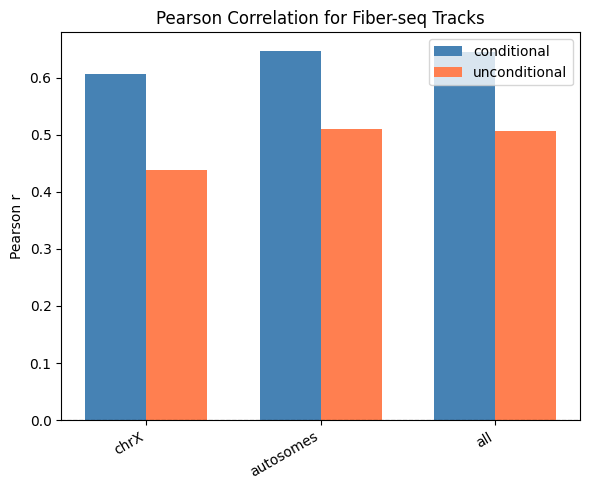

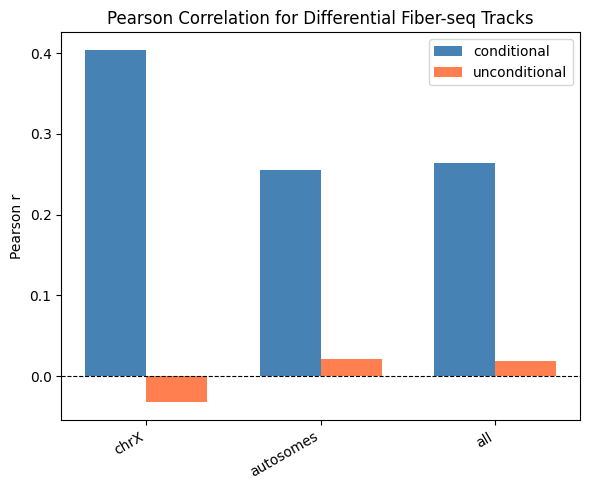

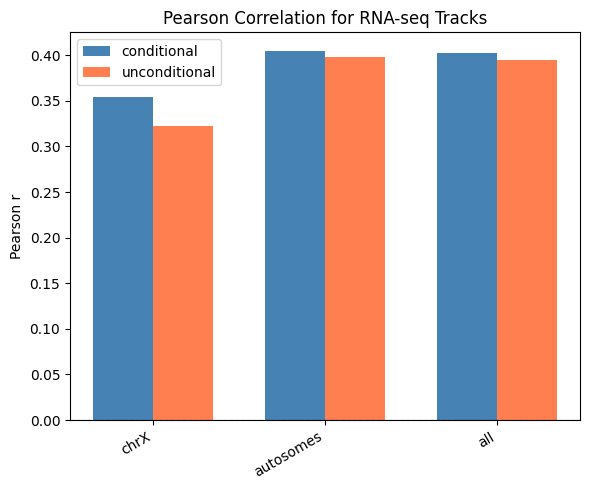

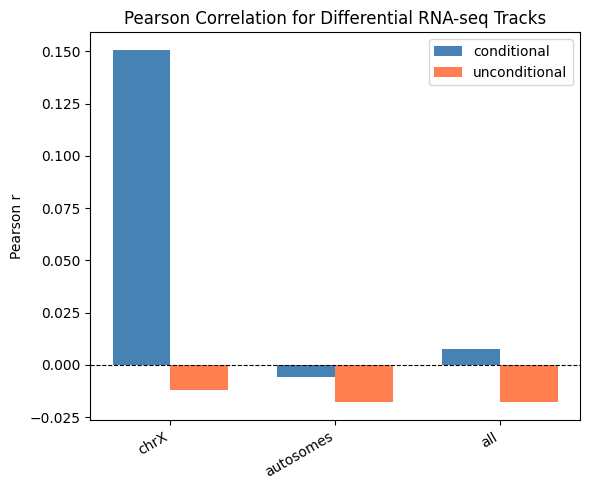

In [21]:
def sig_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'
colors = ['steelblue', 'coral']  # conditional, unconditional

for data_type, correlations_by_description in pearson_correlations_dict.items():
    
    # Collect all descriptions and their values first, to plot on one axis
    descriptions = list(correlations_by_description.keys())
    n_descriptions = len(descriptions)
    n_models = 2  # conditional, unconditional
    bar_width = 0.35
    x = np.arange(n_descriptions)

    for plot_type in ['standard', 'differential']:
        fig, ax = plt.subplots(figsize=(max(6, n_descriptions * 1.5), 5))

        for i, model_idx in enumerate(['conditional', 'unconditional']):
            values, p_values = [], []
            for description, correlations_by_model in correlations_by_description.items():
                corr = list(correlations_by_model.values())[i]
                if plot_type == 'standard':
                    values.append(corr['pearson'])
                    p_values.append(corr['pearson_p'])
                else:
                    values.append(corr['pearson_differential'])
                    p_values.append(corr['pearson_p_differential'])

            offsets = x + (i - 0.5) * bar_width
            bars = ax.bar(offsets, values, width=bar_width, label=model_idx, color=colors[i])

            # for bar, p in zip(bars, p_values):
            #     h = bar.get_height()
            #     y_pos = h + 0.01 if h >= 0 else h - 0.04
            #     ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
            #             f"p={p:.2e}", ha='center', va='bottom', fontsize=8)

        # X-tick labels: strip "conditional"/"unconditional" prefix
        short_labels = []
        for desc in descriptions:
            for prefix in ['conditional_', 'unconditional_', 'conditional', 'unconditional']:
                desc = desc.replace(prefix, '')
            short_labels.append(desc.strip('_'))

        ax.set_xticks(x)
        ax.set_xticklabels(short_labels, rotation=30, ha='right')
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_ylabel('Pearson r')
        ax.legend()
        title_suffix = 'Differential ' if plot_type == 'differential' else ''
        ax.set_title(f'Pearson Correlation for {title_suffix}{data_type} Tracks')
        plt.tight_layout()
        plt.show()